In [1]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD
from line_understanding.pipeline import process_image_pipeline, plot_pipeline_results
from line_understanding.json_saver import save_lines_to_json 


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()



data/DSC_0239/image.jpg
data/DSC_0239/depth.png
data/DSC_0239/meta.json
(682, 1024, 3)
(682, 1024)
(682, 1024, 3)
(682, 1024, 3)
Loading : 0.24956703186035156 seconds!
DeepLSD : 5.717447996139526 seconds!
Sobel : 0.07592391967773438 seconds!
Print Scores
Scores [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0]


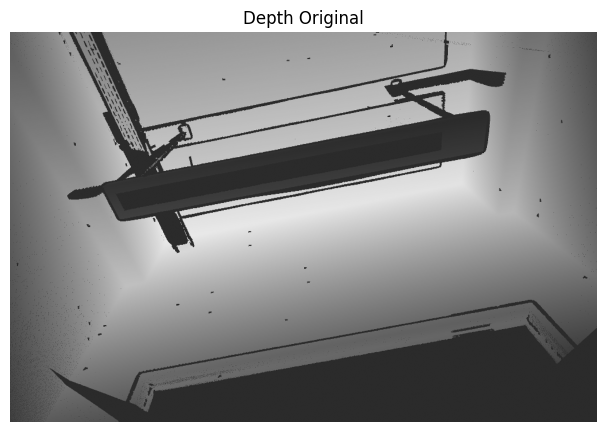

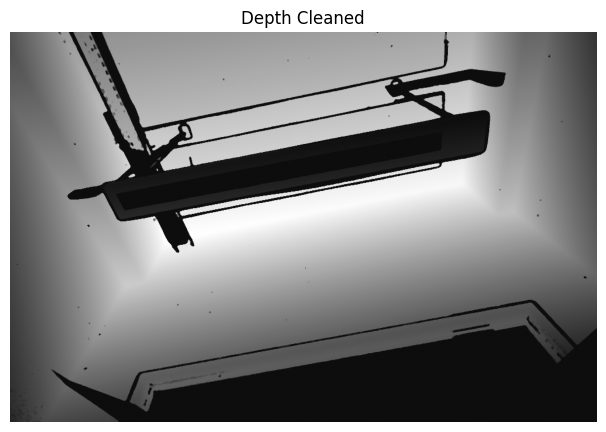

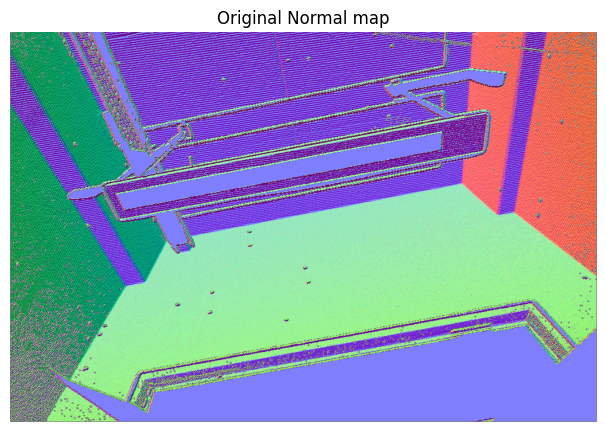

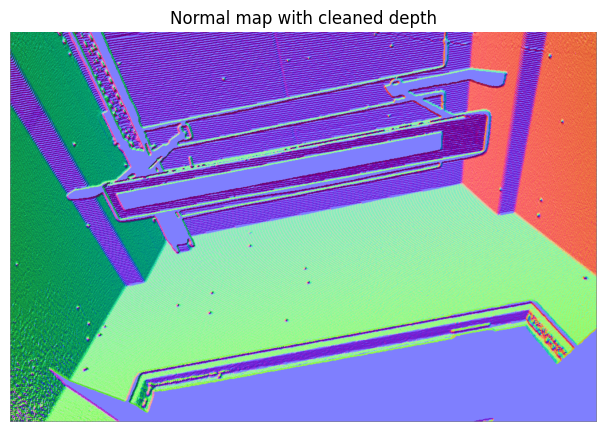

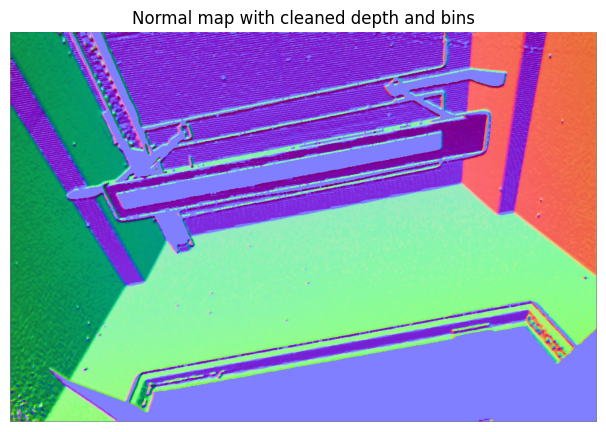

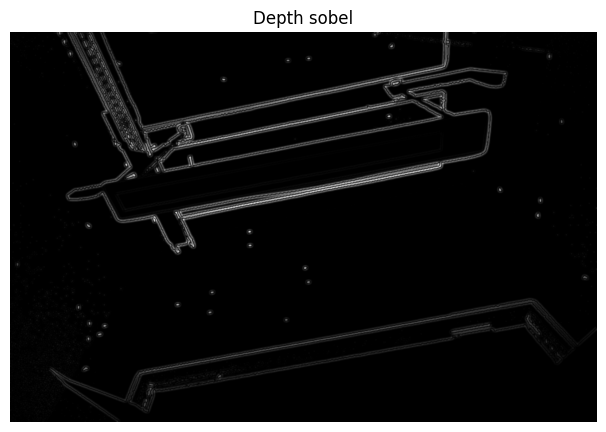

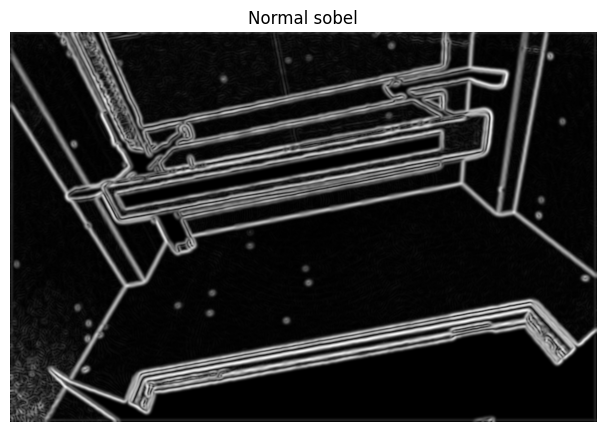

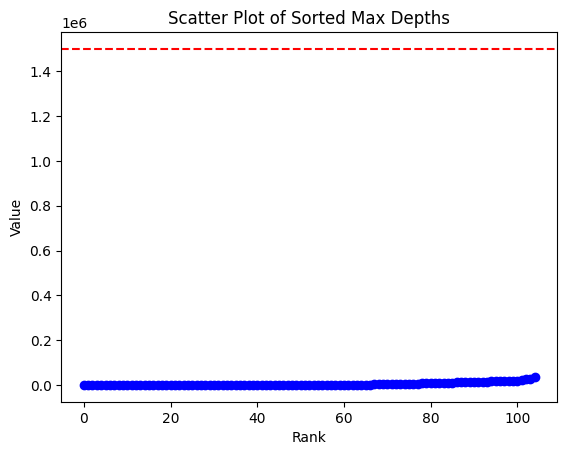

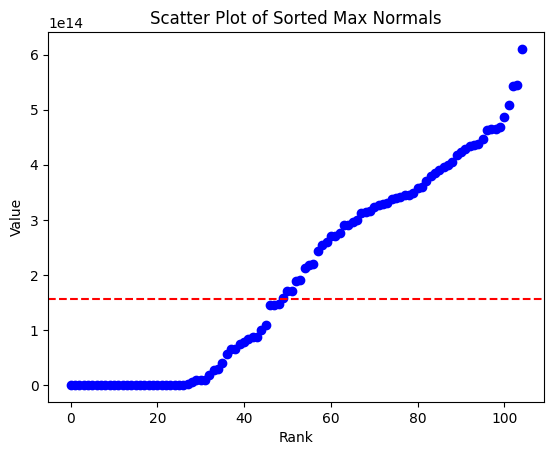

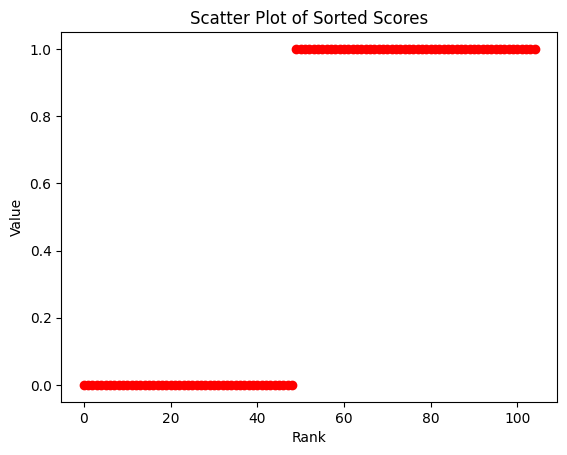

[Neighborhood Method] DSC_0239: Detected 105 lines; 56 structural.
Struct vs Textural : 1.7315828800201416 seconds!
Splitting Lines : 2.23982310295105 seconds!


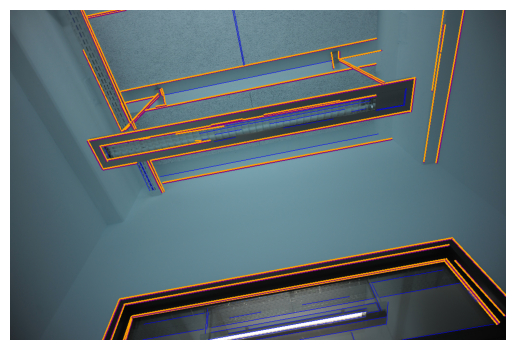

Calculating plane for each pixel : 4.872621774673462 seconds!
World_coordinates 682 1024
start hdbscan


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
frame_str = "0001"
desired_images = [
    "DSC_0239",
    #"DSC_0442",
    #"DSC_0455",
    

    
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    # processed_data = process_image_pipeline(image_id, frame_str, net, device, depth_thresh=0.15*1e7, normal_thresh=(1.25 * 1e7)**2, cluster_selection_epsilon=0.0001, 
    #     min_cluster_size=200, dataset="moge_gt")
    processed_data = process_image_pipeline(image_id, frame_str, net, device, depth_thresh=0.15 * 1e7, normal_thresh=(1.25 * 1e7)**2, cluster_selection_epsilon=0.2, 
        min_cluster_size=10, dataset="moge_gt")
    if processed_data is not None:
        plot_pipeline_results(processed_data, frame_str)